# Twitter Data Analysis

This notebook demonstrates how to use the Twitter API v2 script and analyze the collected data.

In [2]:
import spacy

nlp = spacy.load("en_core_web_sm")
print("spaCy OK")

spaCy OK


In [1]:
# Import necessary libraries
import json
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
import sys, os
import spacy

#spacy.cli.download( "en_core_web_sm" )
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])


# Add custom module path
# load tweets from kaggle(option 2)
sys.path.append("../scripts")
from fetch_tweets import *
from twitterapiv2 import get_all_tweets, default_query_parameters, request_headers

ModuleNotFoundError: No module named 'spacy'

## Step 1: Fetch Tweets

### fetch tweets using Twitter API script.

In [3]:
# Set up headers with your bearer token
bearer_token = os.getenv("X_BEARER_TOKEN")
headers = request_headers(bearer_token)

In [ ]:
# Fetch tweets
tweets = get_all_tweets(
    "https://api.twitter.com/2/tweets/search/recent",
    headers,
    default_query_parameters,
    max_pages=3 # Adjust this number based on your needs
)

print(f"Fetched {len(tweets)} tweets")

Rate limit reached. Sleeping for 906 seconds...


In [ ]:
# Convert to DataFrame
df = pd.DataFrame(tweets)

# Display basic information
print("DataFrame Info:")
df.info()

print("\nFirst few tweets:")
df.head()

In [ ]:
# Basic analysis
print("\nTweet Length Statistics:")

# Convert created_at to datetime
df['created_at'] = pd.to_datetime(df['created_at'])

# Extract engagement metrics
df['retweet_count'] = df['public_metrics'].apply(lambda x: x['retweet_count'])
df['reply_count'] = df['public_metrics'].apply(lambda x: x['reply_count'])
df['like_count'] = df['public_metrics'].apply(lambda x: x['like_count'])
df['quote_count'] = df['public_metrics'].apply(lambda x: x['quote_count'])

# Display basic statistics
print("Engagement Statistics:")
df[['retweet_count', 'reply_count', 'like_count', 'quote_count']].describe()

In [ ]:
# Visualise

# Set style
plt.style.use('seaborn')

# Create a figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Tweet timeline
df.set_index('created_at').resample('D').size().plot(ax=axes[0,0], title='Tweets per Day')

# Plot 2: Engagement metrics
engagement_metrics = ['retweet_count', 'reply_count', 'like_count', 'quote_count']
df[engagement_metrics].boxplot(ax=axes[0,1])
axes[0,1].set_title('Engagement Metrics Distribution')
axes[0,1].tick_params(axis='x', rotation=45)

# Plot 3: Correlation heatmap
sns.heatmap(df[engagement_metrics].corr(), annot=True, ax=axes[1,0])
axes[1,0].set_title('Engagement Metrics Correlation')

# Plot 4: Top 10 most liked tweets
top_liked = df.nlargest(10, 'like_count')[['text', 'like_count']]
top_liked.plot(kind='barh', x='text', y='like_count', ax=axes[1,1])
axes[1,1].set_title('Top 10 Most Liked Tweets')

plt.tight_layout()
plt.show()

In [ ]:
# Save to CSV
df.to_csv('processed_tweets.csv', index=False)
print("Data saved to processed_tweets.csv")

### load from kaggle

In [3]:
# Sentiment140 dataset with 1.6 million tweets from kaggle
df =load_tweets()
df.head()


🔍 How would you like to load tweets?
1. Fetch from Twitter API
2. Load from Kaggle

🔹 Available Datasets:

Dataset 1: krishbaisoya/tweets-sentiment-analysis - Sentiment140
Files:
  - Exploring Data.ipynb (Size: 43137 bytes)
  - test_data.csv (Size: 26885 bytes)
  - train_data.csv (Size: 102946957 bytes)
  - vocab.json (Size: 1183439 bytes)
  - vocab.py (Size: 1110 bytes)

Dataset 2: kazanova/sentiment140 - Sentiment140 dataset with 1.6 million tweets
Files:
  - training.1600000.processed.noemoticon.csv (Size: 238803811 bytes)
⚠️  Failed to read with utf-8 encoding, trying next...
✅ Successfully read with latin1 encoding

✅ Dataset loaded successfully!
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599999 entries, 0 to 1599998
Data columns (total 6 columns):
 #   Column                                                                                                               Non-Null Count    Dtype 
---  ------                                                                     

,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer. You shoulda got David Carr of Third Day to do it. ;D"
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew


In [4]:
df.columns = ["sentiment", "id", "created_at", "query", "user", "text"]
df.head()

,sentiment,id,created_at,query,user,text
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew


## Step 2:  Visualise and Clean tweets

### Visualise

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599999 entries, 0 to 1599998
Data columns (total 6 columns):
 #   Column      Non-Null Count    Dtype 
---  ------      --------------    ----- 
 0   sentiment   1599999 non-null  int64 
 1   id          1599999 non-null  int64 
 2   created_at  1599999 non-null  object
 3   query       1599999 non-null  object
 4   user        1599999 non-null  object
 5   text        1599999 non-null  object
dtypes: int64(2), object(4)
memory usage: 73.2+ MB


In [6]:
# drop irrelevant columns and encode sentiment label if available
tweets_df= df.copy()
tweets_df = drop_and_encode_sentiment(tweets_df)
print(tweets_df.info())
tweets_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1581465 entries, 0 to 1581464
Data columns (total 6 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   sentiment    1581465 non-null  object        
 1   created_at   1581465 non-null  datetime64[ns]
 2   text         1581465 non-null  object        
 3   month        1581465 non-null  object        
 4   day_of_week  1581465 non-null  object        
 5   season       1581465 non-null  object        
dtypes: datetime64[ns](1), object(5)
memory usage: 72.4+ MB
None


,sentiment,created_at,text,month,day_of_week,season
0,negative,2009-04-06 22:19:49,is upset that he can't update his Facebook by ...,April,Monday,Spring
1,negative,2009-04-06 22:19:53,@Kenichan I dived many times for the ball. Man...,April,Monday,Spring
2,negative,2009-04-06 22:19:57,my whole body feels itchy and like its on fire,April,Monday,Spring
3,negative,2009-04-06 22:19:57,"@nationwideclass no, it's not behaving at all....",April,Monday,Spring
4,negative,2009-04-06 22:20:00,@Kwesidei not the whole crew,April,Monday,Spring


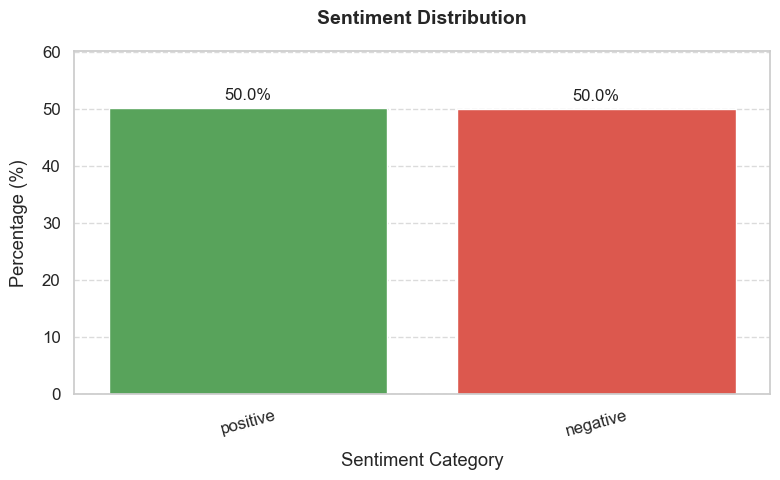

In [ ]:
# Plot sentiment distribution to check imbalance .# Works with various column names like 'Sentiment', 'label', etc.
plot_sentiment_distribution(tweets_df, title="Sentiment Distribution")

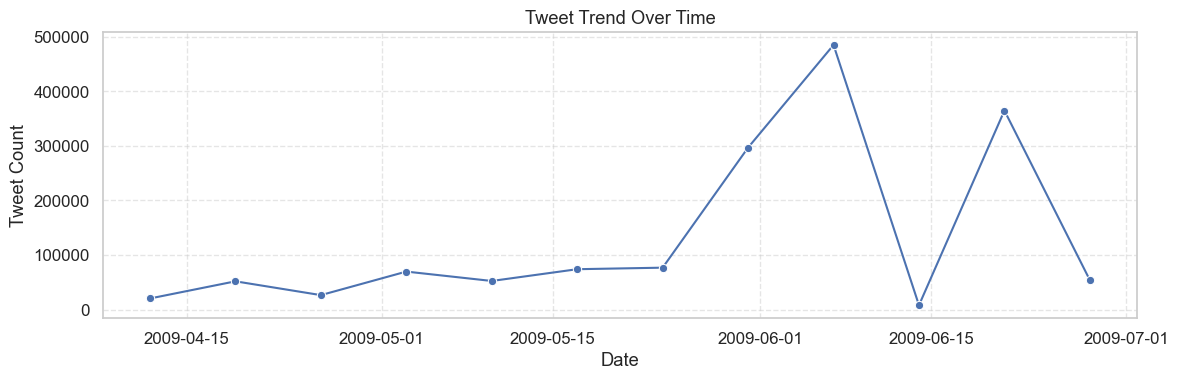

In [19]:
# Plott tweet trend over time
plot_time_trend(tweets_df)

### Clean tweets - Pre-cleaning with regex (vectorized)

In [11]:
# remove_urls, remove_mentions @mentions, remove_hashtags (bool): Remove hashtags (but keep words if False)
# remove non-alphabetic characters, convert text to lowercase
tweets_df["cleaned_text"] = tweets_df["text"].apply(clean_text)
tweets_df.head()

,sentiment,created_at,text,month,day_of_week,season,cleaned_text
0,negative,2009-04-06 22:19:49,is upset that he can't update his Facebook by ...,April,Monday,Spring,is upset that he cant update his facebook by t...
1,negative,2009-04-06 22:19:53,@Kenichan I dived many times for the ball. Man...,April,Monday,Spring,i dived many times for the ball managed to sav...
2,negative,2009-04-06 22:19:57,my whole body feels itchy and like its on fire,April,Monday,Spring,my whole body feels itchy and like its on fire
3,negative,2009-04-06 22:19:57,"@nationwideclass no, it's not behaving at all....",April,Monday,Spring,no its not behaving at all im mad why am i her...
4,negative,2009-04-06 22:20:00,@Kwesidei not the whole crew,April,Monday,Spring,not the whole crew


#### lemmatization + stopword removal - spacy

In [16]:
# Lemmatization + stopword removal - spacy

tweets_df = remove_stopwords(
    tweets_df,
    text_col="cleaned_text",
    new_col="filtered_text"  
)
tweets_df.head()

,sentiment,created_at,text,month,day_of_week,season,cleaned_text,filtered_text
0,negative,2009-04-06 22:19:49,is upset that he can't update his Facebook by ...,April,Monday,Spring,is upset that he cant update his facebook by t...,upset update texting result school today blah
1,negative,2009-04-06 22:19:53,@Kenichan I dived many times for the ball. Man...,April,Monday,Spring,i dived many times for the ball managed to sav...,dived times ball managed save rest bounds
2,negative,2009-04-06 22:19:57,my whole body feels itchy and like its on fire,April,Monday,Spring,my whole body feels itchy and like its on fire,body feels itchy
3,negative,2009-04-06 22:19:57,"@nationwideclass no, it's not behaving at all....",April,Monday,Spring,no its not behaving at all im mad why am i her...,behaving mad
4,negative,2009-04-06 22:20:00,@Kwesidei not the whole crew,April,Monday,Spring,not the whole crew,crew


In [17]:
selected_columns = ["sentiment", "created_at", "filtered_text"]
tweets_subset = tweets_df[selected_columns].copy()  
tweets_subset.head()

,sentiment,created_at,filtered_text
0,negative,2009-04-06 22:19:49,upset update texting result school today blah
1,negative,2009-04-06 22:19:53,dived times ball managed save rest bounds
2,negative,2009-04-06 22:19:57,body feels itchy
3,negative,2009-04-06 22:19:57,behaving mad
4,negative,2009-04-06 22:20:00,crew


## Train a Sentiment Classifier